In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns   

In [2]:
# function to set working directory to the git repository root
def set_working_directory_to_git_root():
    import os
    import subprocess

    # Get the current working directory
    current_dir = os.getcwd()

    # Use git command to find the root directory of the repository
    try:
        git_root = subprocess.check_output(['git', 'rev-parse', '--show-toplevel'], cwd=current_dir).strip().decode('utf-8')
        os.chdir(git_root)
        print(f"Working directory set to git repository root: {git_root}")
    except subprocess.CalledProcessError as e:
        print("Error: Not a git repository or git is not installed.")
        print(e)

set_working_directory_to_git_root()

Working directory set to git repository root: /home/hassan/Documents/Kimel/PhD_1


In [3]:
## demographics

TAY_core = pd.read_csv('CLIN/data/datacut_demographics_core_data.csv')[['subject_id',  'age_enrolment',
       'age_first_assessment_in_month', 'assigned_sex_at_birth', 'prodromal_psychosis', 'gender_diversity', 'gender_identity',
       'ethnicity',
       'family_income' ]]

## from youth report get data on parents education and income


## from caregiver report get data on parents education and income
    # demo_ed_q1 = employment status (primary)
    # demo_ed_q2 = employment status (secondary)
    # demo_ed_q2_nl = employment status (secondary) free text
    # demo_ed_q3 = Are you currently a student?
    # demo_ed_q3_nl = Are you currently a student? free text
    # demo_ed_q4 = What is the highest level of education you have completed? 
    # demo_ed_q4_nl = What is the highest level of education you have completed? free text

TAY_caregiver = pd.read_csv('CLIN/data/demographic_caregiver_data.csv')[['subject_id', 'timepoint' , 'demo_ed_q1', 'demo_ed_q2', "demo_ed_q2_nl", 'demo_ed_q3', 'demo_ed_q4', 'demo_ed_q4_nl']]

## dictionary to convert demo_ed_q4 answers to a common format 
education_dict = {1: 'Some elementary school', 2: 'Some high school', 3: 'High school diploma', 4: 'Trade/vocational/technical certificate/ apprenticeship', 5: 'Some college/technical institute', 6: 'Some University', 7: 'Graduated College', 8: 'Graduated University', 9: 'Certificate college/university', 10: 'Masters degree', 11: 'Doctorate degree', 12: 'Prefer not to answer', 13: 'Not listed (please specify)'}

# for subject_id with two timepoints keep the earliest timepoint
TAY_caregiver['timepoint_num'] = pd.to_numeric(TAY_caregiver['timepoint'], errors='coerce')
TAY_caregiver = (
    TAY_caregiver.sort_values(['subject_id', 'timepoint_num'])
        .drop_duplicates(subset='subject_id', keep='first')
        .drop(columns='timepoint_num')
)
# convert demo_ed_q4 to a common format using the dictionary
TAY_caregiver['parental_education_level'] = TAY_caregiver['demo_ed_q4'].map(education_dict)

# left join TAY_core and TAY_caregiver on subject_id
TAY_core = pd.merge(TAY_core, TAY_caregiver[['subject_id', 'parental_education_level']], on='subject_id', how='left')

## Resilience factors

In [4]:
## parent work type from youth report

ASEBA_youth = pd.read_csv('CLIN/data/aseba/aseba_youth_selfreport_ysr_data.csv')[['subject_id',  "ysr_fworktype", "ysr_mworktype"]]

TAY_parent_work = pd.merge(TAY_caregiver, ASEBA_youth[['subject_id',  "ysr_fworktype", "ysr_mworktype"]], on='subject_id', how='left')

# if there are any values in ysr_fworktype or ysr_mworktype or demo_ed_q1 or demo_ed_q1, then make caregiver_employment = 'Employed'
#  unless ysr_fworktype or ysr_mworktype is 'N.A.', 'MI', 'ASKU', 'UNK', PNA', 'NI then make it NA however, if there are values in demo_ed_q1 or demo_ed_q2 then make caregiver_education_level = 'Employed'  if the values are 2
# 1. Define the list of invalid/missing responses
invalid_work = ['N.A.', 'MI', 'ASKU', 'UNK', 'PNA', 'NI', "Not working", "NASK"]

TAY_parent_work['demo_ed_q1'] = pd.to_numeric(TAY_parent_work['demo_ed_q1'], errors='coerce')
TAY_parent_work['demo_ed_q2'] = pd.to_numeric(TAY_parent_work['demo_ed_q2'], errors='coerce')

# Create boolean conditions for each of your rules
# Check if youth report has valid father/mother work types
valid_fwork = TAY_parent_work['ysr_fworktype'].notna() & ~TAY_parent_work['ysr_fworktype'].isin(invalid_work)
valid_mwork = TAY_parent_work['ysr_mworktype'].notna() & ~TAY_parent_work['ysr_mworktype'].isin(invalid_work)

# Check if caregiver report indicates employment (value == 2)
valid_ed_q1 = TAY_parent_work['demo_ed_q1'] == 2
valid_ed_q2 = TAY_parent_work['demo_ed_q2'] == 2

#  Combine all conditions with OR (|)
is_employed = valid_fwork | valid_mwork | valid_ed_q1 | valid_ed_q2

#Assign the results to the new column
# If is_employed is True -> 'Employed', Else -> pd.NA
TAY_parent_work['caregiver_employment'] = np.where(is_employed, 'Employed', pd.NA)


# 2. Define conditions for Unemployment
# We check if either q1 or q2 is 4 AND they aren't already flagged as employed 
# (e.g., if one parent is 2 and the other is 4, they stay 'Employed')
is_unemployed = (TAY_parent_work['demo_ed_q1'] == 4) | (TAY_parent_work['demo_ed_q2'] == 4)

#  Use np.select to apply the hierarchy
conditions = [
    is_employed,        # Condition 1
    is_unemployed       # Condition 2
]

choices = [
    'Employed',         # Choice for Condition 1
    'Unemployed'        # Choice for Condition 2
]

# If neither condition is met, it defaults to pd.NA
TAY_parent_work['caregiver_employment'] = np.select(conditions, choices, default=pd.NA)

## Adversity measures

In [5]:
### adverse life events scale


''' Adversity in the literature has been cumulated in a dose dependent manner, so we will create a cumulative adversity score, 
    and then also look at specific types of adversity (e.g., abuse, neglect, household dysfunction) 

    we will use the adverse life events scale and if possible from caregiver too to see what we missed from the youth report
'''

ales_youth = pd.read_csv('CLIN/data/adverse_life_events_scale_data.csv')

# Keep only ALE item columns: ales_q1 ... ales_q25 (not q1b/q1c)
item_cols = [c for c in ales_youth.columns if re.fullmatch(r'ales_q\d+', c)]

# Numeric conversion — update in-place on ales_youth AND keep a standalone df
ales_youth[item_cols] = ales_youth[item_cols].apply(pd.to_numeric, errors='coerce')
ales_items = ales_youth[item_cols].copy()

# Count endorsed items (coded as 1) per row
ales_youth['ales_total_score'] = (ales_youth[item_cols] == 1).sum(axis=1).astype(float)

# Keep earliest timepoint per subject
ales_youth['timepoint_num'] = pd.to_numeric(ales_youth['timepoint'], errors='coerce')
ales_youth = (
    ales_youth.sort_values(['subject_id', 'timepoint_num'])
              .drop_duplicates(subset='subject_id', keep='first')
              .drop(columns='timepoint_num')
)

# filter to only those with complete ALES form
ales_youth = ales_youth[ales_youth['ales_form_complete'] == 1].copy()

# make final score numeric (after validation)
ales_youth['ales_total_score'] = pd.to_numeric(ales_youth['ales_total_score'], errors='coerce')

# item label map 
item_labels = {
    'ales_q1':  'Someone in family died',
    'ales_q2':  'Family member seriously injured',
    'ales_q3':  'Saw crime/accident',
    'ales_q4':  'Lost a close friend',
    'ales_q5':  'Close friend seriously sick/injured',
    'ales_q6':  'Negative change in family finances',
    'ales_q7':  'Family member had drug/alcohol problem',
    'ales_q8':  'Got seriously sick or injured',
    'ales_q9':  'Parents argued more than previously',
    'ales_q10': 'Mother/father figure lost job',
    'ales_q11': 'One parent away from home more often',
    'ales_q12': 'Someone in family arrested',
    'ales_q13': 'Close friend died',
    'ales_q14': 'Family member had mental/emotional problem',
    'ales_q15': 'Brother or sister left home',
    'ales_q16': 'Victim of crime/violence/assault',
    'ales_q17': 'Parents separated in last 12 months',
    'ales_q18': 'Parents got into trouble with the law',
    'ales_q19': 'Attended a new school',
    'ales_q20': 'Family moved',
    'ales_q21': 'Parents got divorced',
    'ales_q22': 'One of the parents went to jail',
    'ales_q23': 'Got new stepmother or stepfather',
    'ales_q24': 'Parent got a new job',
    'ales_q25': 'Got new brother or sister',
}

# Per-subject: list of endorsed adversity labels 
def get_endorsed(row):
    return [item_labels[col] for col in item_cols if row[col] == 1]

ales_youth['ALES_endorsed_items'] = ales_youth.apply(get_endorsed, axis=1)

# --- Prevalence table: % of subjects endorsing each item ---
prevalence = (
    pd.DataFrame({
        'item':  list(item_labels.values()),
        'col':   list(item_labels.keys()),
        'n_endorsed': [(ales_youth[col] == 1).sum() for col in item_labels],
    })
    .assign(pct_endorsed=lambda d: (d['n_endorsed'] / len(ales_youth[ales_youth['ales_form_complete'] == 1]) * 100).round(1))
    .sort_values('pct_endorsed', ascending=False)
    .reset_index(drop=True)
)

print(prevalence[['item', 'n_endorsed', 'pct_endorsed']].to_string(index=False))


                                      item  n_endorsed  pct_endorsed
                    Someone in family died         163          45.4
                     Attended a new school         150          41.8
Family member had mental/emotional problem         105          29.2
                       Lost a close friend         102          28.4
           Family member seriously injured          96          26.7
        Negative change in family finances          87          24.2
                        Saw crime/accident          80          22.3
       Parents argued more than previously          78          21.7
      One parent away from home more often          71          19.8
                      Parent got a new job          68          18.9
    Family member had drug/alcohol problem          65          18.1
             Got seriously sick or injured          63          17.5
          Victim of crime/violence/assault          60          16.7
                              Fami

In [6]:


ctq_youth = pd.read_csv('CLIN/data/childhood_trauma_questionnaire_data.csv')

# Item sets 
ctq_item_cols = [c for c in ctq_youth.columns if re.fullmatch(r'ctq_q\d+', c)]

CTQ_PROTECTIVE_ITEMS = ['ctq_q6', 'ctq_q7', 'ctq_q8', 'ctq_q9', 'ctq_q10', 'ctq_q16', 'ctq_q17'] ## we will keep these separate
CTQ_TRAUMA_ITEMS     = [c for c in ctq_item_cols if c not in CTQ_PROTECTIVE_ITEMS] ## adversity 

# binary-encode all items (>= 2 → 1, else 0, missing → NaN)
ctq_binary = ctq_youth[ctq_item_cols].apply(
    lambda col: col.map(lambda v: np.nan if pd.isna(v) else int(v >= 2))
)

# helper function: sum endorsed items in a subset, but if all items are missing then return NA (not 0)
# All missing → NA; partial missing → sum available items
def score_subset(binary_df, cols):
    subset = binary_df[cols]
    return subset.apply(
        lambda row: pd.NA if row.isna().all() else row.sum(min_count=1),
        axis=1
    )

ctq_youth['ctq_adversity_score']  = score_subset(ctq_binary, CTQ_TRAUMA_ITEMS)
ctq_youth['ctq_resilience_score'] = score_subset(ctq_binary, CTQ_PROTECTIVE_ITEMS)

# Validation: score == 0 must have no endorsed items in that subscale 
def validate_score(row, score_col, item_cols):
    val = row[score_col]
    if pd.isna(val) or val != 0:
        return val
    for col in item_cols:
        if col in row.index and pd.notna(row[col]) and row[col] >= 2:
            return pd.NA  # contradiction
    return 0

ctq_youth['ctq_adversity_score'] = ctq_youth.apply(
    lambda r: validate_score(r, 'ctq_adversity_score', CTQ_TRAUMA_ITEMS), axis=1
)
ctq_youth['ctq_resilience_score'] = ctq_youth.apply(
    lambda r: validate_score(r, 'ctq_resilience_score', CTQ_PROTECTIVE_ITEMS), axis=1
)

# make final score columns numeric (after validation)
ctq_youth['ctq_adversity_score'] = pd.to_numeric(ctq_youth['ctq_adversity_score'], errors='coerce')
ctq_youth['ctq_resilience_score'] = pd.to_numeric(ctq_youth['ctq_resilience_score'], errors='coerce')

# Item label map
ctq_item_labels = {
    'ctq_q1':  'Hit so hard needed medical attention',
    'ctq_q2':  'Family hit leaving bruises or marks',
    'ctq_q3':  'Beaten so badly it was noticed by others',
    'ctq_q4':  'Punished with belt/board/cord/hard object',
    'ctq_q5':  'Believes they were physically abused',
    'ctq_q6':  'Family felt close to each other',
    'ctq_q7':  'Felt loved',
    'ctq_q8':  'Someone made them feel important/special',
    'ctq_q9':  'Family looked out for each other',
    'ctq_q10': 'Family was source of strength/support',
    'ctq_q11': 'Family said hurtful or insulting things',
    'ctq_q12': 'Family called stupid, lazy, or ugly',
    'ctq_q13': 'Felt someone in family hated them',
    'ctq_q14': 'Thought parents wished they were never born',
    'ctq_q15': 'Believes they were emotionally abused',
    'ctq_q16': 'Knew someone to take care/protect them',
    'ctq_q17': 'Someone to take them to the doctor',
    'ctq_q18': "Didn't have enough to eat",
    'ctq_q19': 'Parents too drunk/high to care for family',
    'ctq_q20': 'Had to wear dirty clothes',
    'ctq_q21': 'Believes they were sexually abused',
    'ctq_q22': 'Someone molested them',
    'ctq_q23': 'Someone touched them sexually / made them touch',
    'ctq_q24': 'Someone made them do/watch sexual things',
    'ctq_q25': 'Someone threatened them unless they did something sexual',
}

# Endorsed items per subject (separate lists)─
def get_endorsed(row, cols):
    return [ctq_item_labels[col] for col in cols
            if pd.notna(row[col]) and row[col] >= 2]

ctq_youth['ctq_adversity_endorsed']  = ctq_youth.apply(lambda r: get_endorsed(r, CTQ_TRAUMA_ITEMS), axis=1)
ctq_youth['ctq_resilience_endorsed'] = ctq_youth.apply(lambda r: get_endorsed(r, CTQ_PROTECTIVE_ITEMS), axis=1)




# Prevalence tables
n_valid = ctq_youth['ctq_adversity_score'].notna().sum()

def prevalence_table(cols):
    return (
        pd.DataFrame({
            'item':       [ctq_item_labels[c] for c in cols],
            'col':        cols,
            'n_endorsed': [(ctq_youth[c].ge(2) & ctq_youth[c].notna()).sum() for c in cols],
        })
        .assign(pct_endorsed=lambda d: (d['n_endorsed'] / n_valid * 100).round(1))
        .sort_values('pct_endorsed', ascending=False)
        .reset_index(drop=True)
    )

print("ADVERSITY ITEMS")
print(prevalence_table(CTQ_TRAUMA_ITEMS)[['item', 'n_endorsed', 'pct_endorsed']].to_string(index=False))

print("\nRESILIENCE / PROTECTIVE ITEMS")
print(prevalence_table(CTQ_PROTECTIVE_ITEMS)[['item', 'n_endorsed', 'pct_endorsed']].to_string(index=False))

ADVERSITY ITEMS
                                                    item  n_endorsed  pct_endorsed
                 Family said hurtful or insulting things         588          79.9
                     Family called stupid, lazy, or ugly         553          75.1
                       Felt someone in family hated them         478          64.9
                   Believes they were emotionally abused         425          57.7
             Thought parents wished they were never born         386          52.4
                               Didn't have enough to eat         216          29.3
                    Believes they were physically abused         210          28.5
         Someone touched them sexually / made them touch         180          24.5
               Punished with belt/board/cord/hard object         172          23.4
                     Family hit leaving bruises or marks         172          23.4
                      Believes they were sexually abused         141   

In [7]:
### life events checklist

life_events_scale = pd.read_csv("CLIN/data/life_events_checklist_data.csv")
lec_item_cols = [c for c in life_events_scale.columns if re.fullmatch(r'lec_q\d+', c)]

for col in lec_item_cols:
    life_events_scale[col] = pd.to_numeric(life_events_scale[col], errors='coerce')

# Item label map 
lec_item_labels = {
    'lec_q1':  'Natural disaster (flood, hurricane, tornado, earthquake)',
    'lec_q2':  'Fire or explosion',
    'lec_q3':  'Transportation accident (car, boat, train, plane)',
    'lec_q4':  'Serious accident at work, home, or recreation',
    'lec_q5':  'Exposure to toxic substance (chemicals, radiation)',
    'lec_q6':  'Physical assault (attacked, hit, slapped, kicked, beaten)',
    'lec_q7':  'Assault with a weapon (shot, stabbed, threatened with weapon)',
    'lec_q8':  'Sexual assault (rape, attempted rape, forced sexual act)',
    'lec_q9':  'Other unwanted or uncomfortable sexual experience',
    'lec_q10': 'Combat or exposure to war-zone (military or civilian)',
    'lec_q11': 'Captivity (kidnapped, abducted, hostage, prisoner of war)',
    'lec_q12': 'Life-threatening illness or injury',
    'lec_q13': 'Severe human suffering',
    'lec_q14': 'Sudden, violent death (homicide, suicide)',
    'lec_q15': 'Sudden, unexpected death of someone close',
    'lec_q16': 'Serious injury, harm, or death you caused to someone else',
    'lec_q17': 'Any other stressful event or experience',
}

# ── Binary-encode: 1 if happened to me (== 4), 0 otherwise, NaN if missing ───
# Note: 0 ("doesn't apply") and 1 ("not sure") are meaningfully different from missing,
# so only true NaN (no response) is treated as missing.
lec_binary = life_events_scale[lec_item_cols].apply(
    lambda col: col.map(lambda v: np.nan if pd.isna(v) else int(v == 4))
)

# Score: count of directly experienced events 
life_events_scale['lec_total_score'] = lec_binary.apply(
    lambda row: pd.NA if row.isna().all() else row.sum(min_count=1),
    axis=1
)

# Validate: score == 0 must have no endorsed items 
def validate_lec_total(row):
    if pd.isna(row['lec_total_score']) or row['lec_total_score'] != 0:
        return row['lec_total_score']
    for col in lec_item_cols:
        if col in row.index and pd.notna(row[col]) and row[col] == 4:
            return pd.NA  # contradiction
    return 0

life_events_scale['lec_total_score'] = life_events_scale.apply(validate_lec_total, axis=1)

# Endorsed items per subject 
def get_lec_endorsed(row):
    return [lec_item_labels[col] for col in lec_item_cols
            if pd.notna(row[col]) and row[col] == 4]

life_events_scale['lec_endorsed_items'] = life_events_scale.apply(get_lec_endorsed, axis=1)

# for subject_id with two timepoints keep the earliest timepoint 
life_events_scale['timepoint_num'] = pd.to_numeric(life_events_scale['timepoint'], errors='coerce')
life_events_scale = (
    life_events_scale.sort_values(['subject_id', 'timepoint_num'])
        .drop_duplicates(subset='subject_id', keep='first')
        .drop(columns='timepoint_num')
)

# make the final score numeric (count of endorsed items) rather than binary-encoded
life_events_scale['lec_total_score'] = pd.to_numeric(life_events_scale['lec_total_score'], errors='coerce')


#  Prevalence table 
n_valid = life_events_scale['lec_total_score'].notna().sum()

lec_prevalence = (
    pd.DataFrame({
        'item':       list(lec_item_labels.values()),
        'col':        list(lec_item_labels.keys()),
        'n_endorsed': [(life_events_scale[c] == 4).sum() for c in lec_item_labels],
    })
    .assign(pct_endorsed=lambda d: (d['n_endorsed'] / n_valid * 100).round(1))
    .sort_values('pct_endorsed', ascending=False)
    .reset_index(drop=True)
)

print(f"LIFE EVENTS CHECKLIST — Directly Experienced")
print(lec_prevalence[['item', 'n_endorsed', 'pct_endorsed']].to_string(index=False))

LIFE EVENTS CHECKLIST — Directly Experienced
                                                         item  n_endorsed  pct_endorsed
            Other unwanted or uncomfortable sexual experience         235          60.7
    Physical assault (attacked, hit, slapped, kicked, beaten)         182          47.0
                      Any other stressful event or experience         174          45.0
     Sexual assault (rape, attempted rape, forced sexual act)         141          36.4
            Transportation accident (car, boat, train, plane)         112          28.9
                Serious accident at work, home, or recreation          55          14.2
Assault with a weapon (shot, stabbed, threatened with weapon)          49          12.7
                           Life-threatening illness or injury          43          11.1
     Natural disaster (flood, hurricane, tornado, earthquake)          41          10.6
                                       Severe human suffering          34  

In [8]:
## neighbourhood safety


# Scale: 1=Strongly Agree → 5=Strongly Disagree (higher = less safe = more adversity)
# Binary threshold: >= 4 (Disagree or Strongly Disagree)
# No reverse-scoring needed — all items are same direction (safety = low score)

nscs = pd.read_csv("CLIN/data/neighborhood_safetycrime_youth_data.csv")
nscs_item_cols = [c for c in nscs.columns if re.fullmatch(r'nscs_q\d+', c)]

for col in nscs_item_cols:
    nscs[col] = pd.to_numeric(nscs[col], errors='coerce')

# Item label map 
nscs_item_labels = {
    'nscs_q1': 'Does not feel safe walking in neighborhood day or night',
    'nscs_q2': 'Violence is a problem in neighborhood',
    'nscs_q3': 'Neighborhood is not safe from crime',
}

#  if unsafe (>= 4), 0 if safe/neutral, NaN if missing 
nscs_binary = nscs[nscs_item_cols].apply(
    lambda col: col.map(lambda v: np.nan if pd.isna(v) else int(v >= 4))
)

# Binary count (0–3, number of unsafe endorsements) 
nscs['nscs_unsafe_score'] = nscs_binary.apply(
    lambda row: pd.NA if row.isna().all() else row.sum(min_count=1),
    axis=1
)

# Likert sum (3–15, higher = greater perceived unsafety) 
nscs['nscs_likert_score'] = nscs[nscs_item_cols].apply(
    lambda row: pd.NA if row.isna().all() else row.sum(min_count=1),
    axis=1
)

# Validate binary: score == 0 must have no unsafe endorsements
def validate_nscs(row):
    if pd.isna(row['nscs_unsafe_score']) or row['nscs_unsafe_score'] != 0:
        return row['nscs_unsafe_score']
    for col in nscs_item_cols:
        if col in row.index and pd.notna(row[col]) and row[col] >= 4:
            return pd.NA
    return 0

nscs['nscs_unsafe_score'] = nscs.apply(validate_nscs, axis=1)

# Endorsed items per subject (items perceived as unsafe) 
def get_nscs_endorsed(row):
    return [nscs_item_labels[col] for col in nscs_item_cols
            if pd.notna(row[col]) and row[col] >= 4]

nscs['nscs_endorsed_items'] = nscs.apply(get_nscs_endorsed, axis=1)

# for subject_id with two timepoints keep the earliest timepoint 
nscs['timepoint_num'] = pd.to_numeric(nscs['timepoint'], errors='coerce')
nscs = (
    nscs.sort_values(['subject_id', 'timepoint_num'])
        .drop_duplicates(subset='subject_id', keep='first')
        .drop(columns='timepoint_num')
)

# make the final scores numeric (after validation)
nscs['nscs_unsafe_score'] = pd.to_numeric(nscs['nscs_unsafe_score'], errors='coerce')
nscs['nscs_likert_score'] = pd.to_numeric(nscs['nscs_likert_score'], errors='coerce')

# Prevalence table 
n_valid = nscs['nscs_unsafe_score'].notna().sum()

nscs_prevalence = (
    pd.DataFrame({
        'item':       list(nscs_item_labels.values()),
        'col':        list(nscs_item_labels.keys()),
        'n_endorsed': [(nscs[c] >= 4).sum() for c in nscs_item_labels],
        'mean_likert': [nscs[c].mean().round(2) for c in nscs_item_labels],
    })
    .assign(pct_endorsed=lambda d: (d['n_endorsed'] / n_valid * 100).round(1))
    .sort_values('pct_endorsed', ascending=False)
    .reset_index(drop=True)
)

print(f"=== NEIGHBORHOOD SAFETY — Perceived Unsafety (N valid = {n_valid}) ===")
print(nscs_prevalence[['item', 'n_endorsed', 'pct_endorsed', 'mean_likert']].to_string(index=False))

print(f"\nBinary score (0–3):  mean = {nscs['nscs_unsafe_score'].mean():.2f}, "
      f"sd = {nscs['nscs_unsafe_score'].std():.2f}")
print(f"Likert score (3–15): mean = {nscs['nscs_likert_score'].mean():.2f}, "
      f"sd = {nscs['nscs_likert_score'].std():.2f}")

=== NEIGHBORHOOD SAFETY — Perceived Unsafety (N valid = 737) ===
                                                   item  n_endorsed  pct_endorsed  mean_likert
                    Neighborhood is not safe from crime         182          24.7         2.66
                  Violence is a problem in neighborhood         150          20.4         2.51
Does not feel safe walking in neighborhood day or night         146          19.8         2.46

Binary score (0–3):  mean = 0.65, sd = 0.99
Likert score (3–15): mean = 7.63, sd = 2.90


In [9]:
## make TAY_mastersheet

TAY_mastersheet = pd.merge(TAY_core, TAY_parent_work[['subject_id', 'caregiver_employment']], on='subject_id', how='left')

# also merge ales_total_score and endorsed items
TAY_mastersheet = pd.merge(TAY_mastersheet, ales_youth[['subject_id', 'ales_total_score', 'ALES_endorsed_items']], on='subject_id', how='left')

# also merge ctq adversity/resilience scores and endorsed items
TAY_mastersheet = pd.merge(TAY_mastersheet, ctq_youth[['subject_id', 'ctq_adversity_score', 'ctq_resilience_score', 'ctq_adversity_endorsed', 'ctq_resilience_endorsed']], on='subject_id', how='left')

# also merge life events checklist total score and endorsed items
TAY_mastersheet = pd.merge(TAY_mastersheet, life_events_scale[['subject_id', 'lec_total_score', 'lec_endorsed_items']], on='subject_id', how='left')

# also merge neighborhood safety binary and likert scores and endorsed items
TAY_mastersheet = pd.merge(TAY_mastersheet, nscs[['subject_id', 'nscs_unsafe_score', 'nscs_likert_score', 'nscs_endorsed_items']], on='subject_id', how='left')

# make an adversity count variable that sums ALES, CTQ adversity items, and LEC total score (all binary counts)
TAY_mastersheet['adversity_count'] = TAY_mastersheet[['ales_total_score', 'ctq_adversity_score', 'lec_total_score']].sum(axis=1, min_count=1)


# check datatypes of all the adversity scores
print(TAY_mastersheet[['ales_total_score', 'ctq_adversity_score', 'ctq_resilience_score', 'lec_total_score', 'nscs_unsafe_score', 'nscs_likert_score']].dtypes)


# describe all adversity scores
print(TAY_mastersheet[['ales_total_score', 'ctq_adversity_score', 'ctq_resilience_score', 'lec_total_score', 'nscs_unsafe_score', 'nscs_likert_score', 'adversity_count']].describe())

ales_total_score        float64
ctq_adversity_score     float64
ctq_resilience_score    float64
lec_total_score         float64
nscs_unsafe_score       float64
nscs_likert_score       float64
dtype: object
       ales_total_score  ctq_adversity_score  ctq_resilience_score  \
count        359.000000            736.00000            735.000000   
mean           4.247911              5.85462              6.508844   
std            3.655919              4.28753              1.162360   
min            0.000000              0.00000              0.000000   
25%            2.000000              3.00000              7.000000   
50%            3.000000              5.00000              7.000000   
75%            6.000000              9.00000              7.000000   
max           20.000000             18.00000              7.000000   

       lec_total_score  nscs_unsafe_score  nscs_likert_score  adversity_count  
count       387.000000         737.000000          737.00000       757.000000  
mea

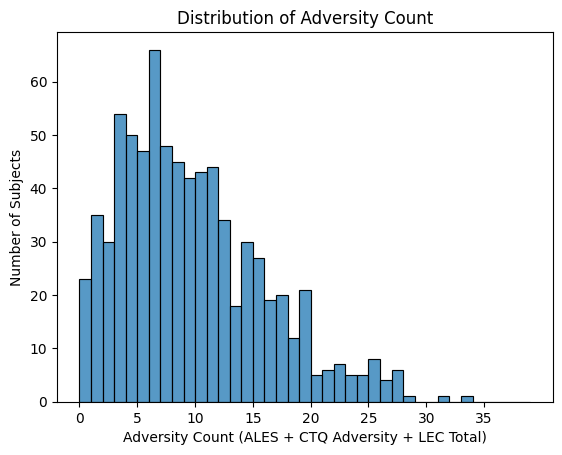

In [11]:
## plot distribution of adversity count

sns.histplot(TAY_mastersheet['adversity_count'].dropna(), bins=range(0, 40), kde=False)
plt.title('Distribution of Adversity Count')
plt.xlabel('Adversity Count (ALES + CTQ Adversity + LEC Total)')
plt.ylabel('Number of Subjects')
plt.xticks(range(0, 40, 5))
plt.show()